MobileSphere: Mobile Price Prediction and Market Analysis using Machine Learning”

Data Gathering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()



In [2]:
df = pd.read_csv("data/cleaned_mobile_data.csv")
df.head()



,Unnamed: 0,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
0,0,OnePlus 7T Pro McLaren Edition,OnePlus,7T Pro McLaren Edition,4085,6.67,Yes,1440,3120,8,...,48.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,58998
1,1,Realme X2 Pro,Realme,X2 Pro,4000,6.50,Yes,1080,2400,8,...,64.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,27999
2,2,iPhone 11 Pro Max,Apple,iPhone 11 Pro Max,3969,6.50,Yes,1242,2688,6,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,106900
3,3,iPhone 11,Apple,iPhone 11,3110,6.10,Yes,828,1792,6,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,62900
4,4,LG G8X ThinQ,LG,G8X ThinQ,4000,6.40,Yes,1080,2340,8,...,12.0,32.0,Android,Yes,Yes,Yes,1,No,No,49990


DATA CLEANING

In [3]:
df.info()
df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1359 non-null   int64  
 1   Name                    1359 non-null   object 
 2   Brand                   1359 non-null   object 
 3   Model                   1359 non-null   object 
 4   Battery capacity (mAh)  1359 non-null   int64  
 5   Screen size (inches)    1359 non-null   float64
 6   Touchscreen             1359 non-null   object 
 7   Resolution x            1359 non-null   int64  
 8   Resolution y            1359 non-null   int64  
 9   Processor               1359 non-null   int64  
 10  RAM (MB)                1359 non-null   int64  
 11  Internal storage (GB)   1359 non-null   float64
 12  Rear camera             1359 non-null   float64
 13  Front camera            1359 non-null   float64
 14  Operating system        1359 non-null   

EDA 

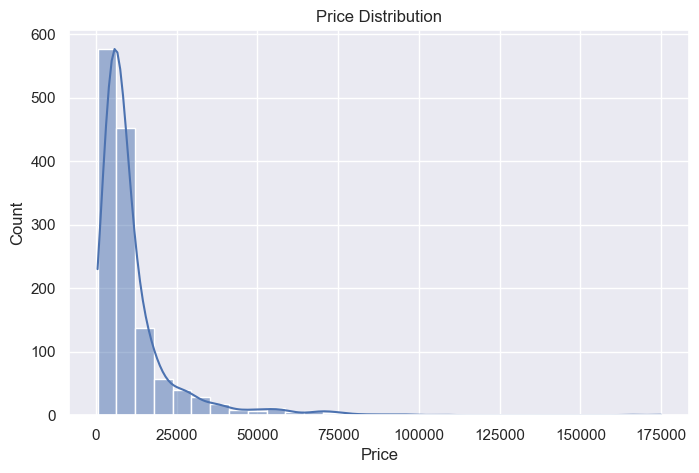

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()



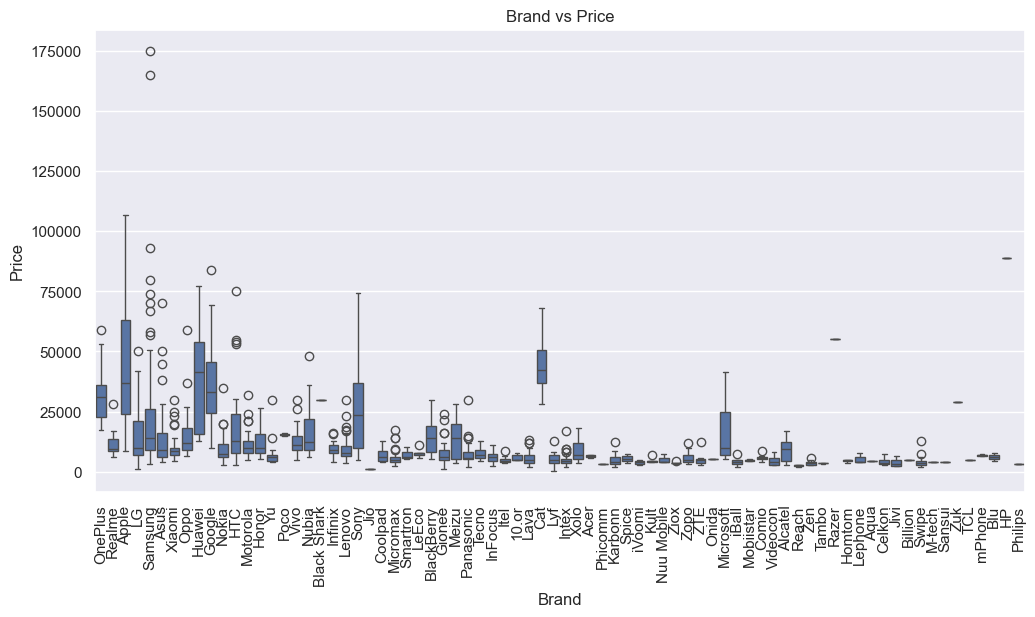

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Brand', y='Price', data=df)
plt.xticks(rotation=90)
plt.title("Brand vs Price")
plt.show()



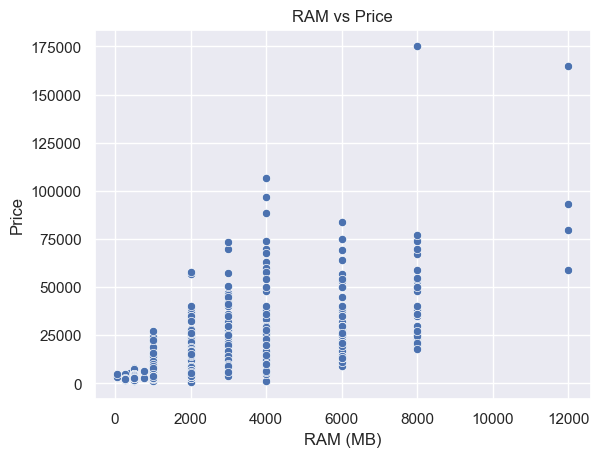

In [6]:
sns.scatterplot(x='RAM (MB)', y='Price', data=df)
plt.title("RAM vs Price")
plt.show()



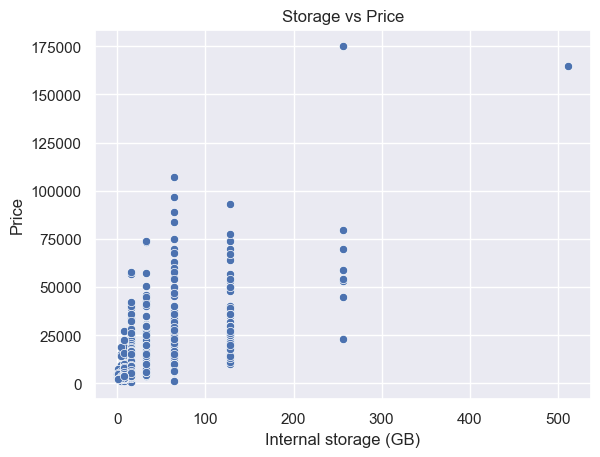

In [7]:
sns.scatterplot(x='Internal storage (GB)', y='Price', data=df)
plt.title("Storage vs Price")
plt.show()



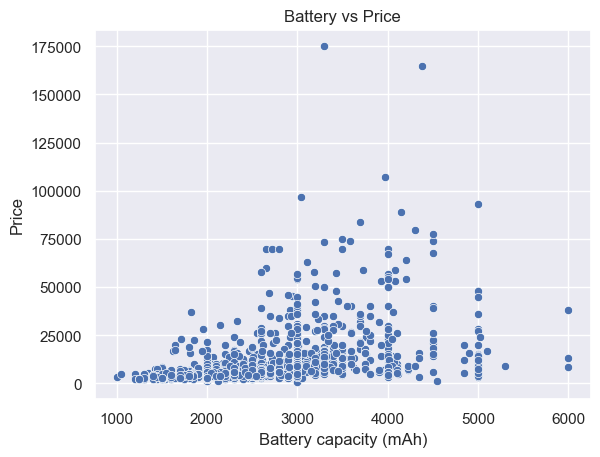

In [8]:
sns.scatterplot(x='Battery capacity (mAh)', y='Price', data=df)
plt.title("Battery vs Price")
plt.show()



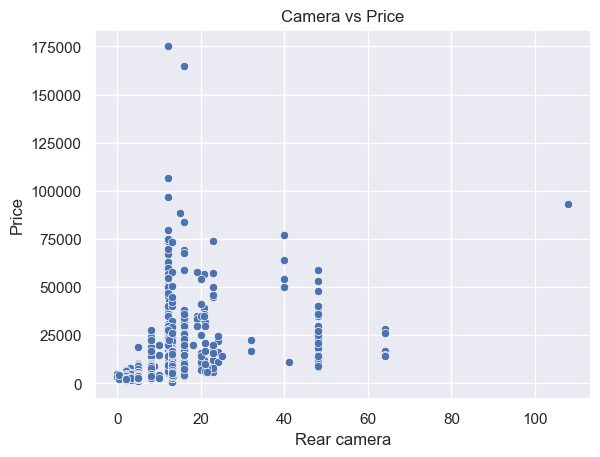

In [9]:
sns.scatterplot(x='Rear camera', y='Price', data=df)
plt.title("Camera vs Price")
plt.show()



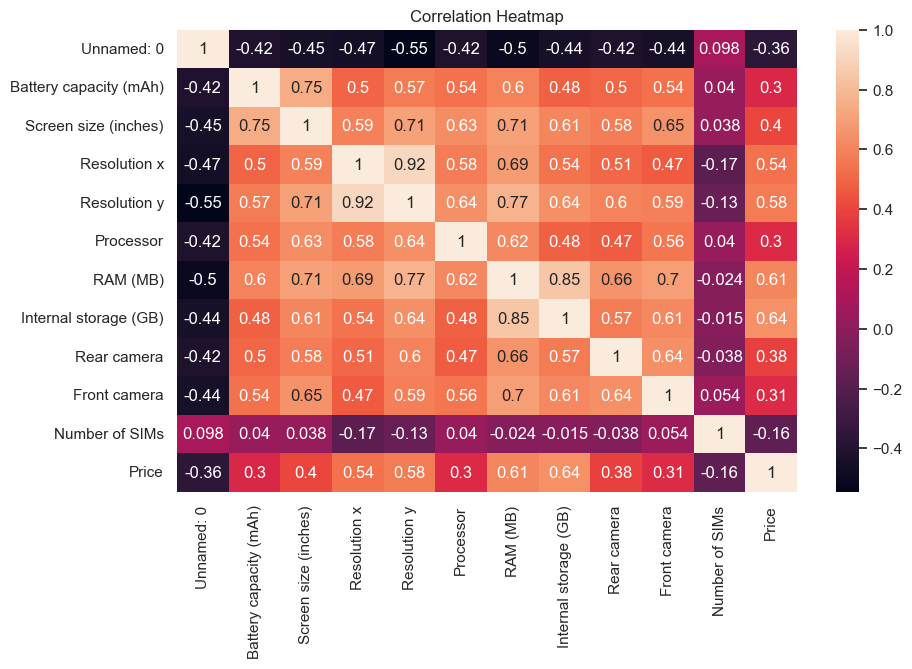

In [10]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()



FEATURE ENCODING

In [11]:
df = pd.get_dummies(df, drop_first=True)



In [12]:
import pickle

# columns = X.columns
# pickle.dump(columns, open("columns.pkl", "wb"))



TRAIN AND TEST 

In [13]:

# Fixes added to correctly prepare and encode inputs
if "Unnamed: 0" in df.columns: df = df.drop("Unnamed: 0", axis=1)
if "Name" in df.columns: df = df.drop("Name", axis=1)
if "Model" in df.columns: df = df.drop("Model", axis=1)

X = df.drop("Price", axis=1)
y = df["Price"]

X_encoded = pd.get_dummies(X)

import pickle
columns = X_encoded.columns
with open("columns.pkl", "wb") as f:
    pickle.dump(columns, f)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)



In [14]:
# Scaler removed: Random Forests do not need standardization.
# x_train = scaler.fit_transform(x_train)


MACHINE LEARNING MODELS

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
pred_lr = lr.predict(x_test)



In [16]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
pred_dt = dt.predict(x_test)



In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)



In [18]:
import pickle
pickle.dump(rf, open("mobile_model.pkl", "wb"))



In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

gb.fit(x_train, y_train)
pred_gb = gb.predict(x_test)



MODEL COMPARISON

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np

models = {
    "Linear": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boost": pred_gb
}

for name, pred in models.items():
    print(name)
    print("R2:", r2_score(y_test, pred))
    print("MAE:", mean_absolute_error(y_test, pred))
    print("MSE:", mean_squared_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("------")



Linear
R2: 0.7073812381812544
MAE: 4791.737841594844
MSE: 77131467.68266824
RMSE: 8782.452259060008
------
Decision Tree
R2: 0.5272331504138412
MAE: 4643.073529411765
MSE: 124616756.47058824
RMSE: 11163.187558694346
------
Random Forest
R2: 0.6356639564068377
MAE: 3942.400914866949
MSE: 96035447.61577542
RMSE: 9799.767732746293
------
Gradient Boost
R2: 0.7136018627545464
MAE: 3727.058777843306
MSE: 75491771.37523158
RMSE: 8688.600081441864
------


In [21]:
from sklearn.metrics import r2_score

print("Random Forest R2:", r2_score(y_test, pred_rf))
print("Gradient Boost R2:", r2_score(y_test, pred_gb))



Random Forest R2: 0.6356639564068377
Gradient Boost R2: 0.7136018627545464


In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(x_train, y_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [23]:
# Cell disabled to prevent conflicting duplicate models.
